In [1]:
# =========================================================
# NOTEBOOK: 05_statistical_analysis.ipynb
# =========================================================


# =========================================================
# STEP 1 — IMPORT LIBRARIES
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind
from scipy.stats import pearsonr
from scipy.stats import spearmanr
from scipy.stats import f_oneway
from scipy.stats import zscore
from scipy.stats import skew
from scipy.stats import kurtosis

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [2]:
# =========================================================
# STEP 2 — LOAD FEATURE ENGINEERED DATASET
# =========================================================

master_df = pd.read_csv(
    r'C:\Users\niran\Desktop\AI_Ecommerce_Customer_Intelligence_Platform\data\processed\feature_engineered_dataset.csv'
)

print("Feature Engineered Dataset Loaded Successfully")

Feature Engineered Dataset Loaded Successfully


In [3]:
# =========================================================
# STEP 3 — DATASET OVERVIEW
# =========================================================

print("\n================ DATASET INFO ================\n")

print(master_df.info())

print("\nDataset Shape:")
print(master_df.shape)


================ DATASET INFO ================

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2530433 entries, 0 to 2530432
Data columns (total 87 columns):
 #   Column                         Dtype  
---  ------                         -----  
 0   order_id                       object 
 1   customer_id                    object 
 2   order_status                   object 
 3   order_purchase_timestamp       object 
 4   order_approved_at              object 
 5   order_delivered_carrier_date   object 
 6   order_delivered_customer_date  object 
 7   order_estimated_delivery_date  object 
 8   delivery_duration_days         float64
 9   delivery_delay_days            float64
 10  approval_time_hours            float64
 11  purchase_month                 int64  
 12  purchase_year                  int64  
 13  purchase_weekday               int64  
 14  customer_unique_id             object 
 15  customer_gender                int64  
 16  customer_age                   int64  
 1

In [4]:
# =========================================================
# STEP 4 — NUMERICAL FEATURE SUMMARY
# =========================================================

print("\n================ NUMERICAL SUMMARY ================\n")

display(master_df.describe())


================ NUMERICAL SUMMARY ================



,delivery_duration_days,delivery_delay_days,approval_time_hours,purchase_month,purchase_year,purchase_weekday,customer_gender,customer_age,customer_zip_code_prefix,customer_segment,order_item_id,price_x,freight_value,discount_rate,product_category_name,product_brand,product_weight_g,product_length_cm,product_height_cm,product_width_cm,cost,price_y,seller_contact_age,seller_zip_code_prefix,payment_sequential,payment_type,payment_installments,payment_value,review_score,purchase_day,purchase_hour,purchase_weekend,review_length,review_word_count,total_orders,total_spent,avg_order_value,avg_review_score,avg_delivery_delay,unique_products_purchased,Recency,Frequency,Monetary,churn,product_revenue,product_total_orders,product_avg_review,product_avg_delay,seller_total_revenue,seller_total_orders,seller_avg_review,seller_avg_delay
count,2.530433e+06,2.530433e+06,2.530433e+06,2.530433e+06,2.530433e+06,2.530433e+06,2.530433e+06,2.530433e+06,2.530433e+06,2.530433e+06,2.530433e+06,2.530433e+06,2.530433e+06,2530433.0,2.530433e+06,2.530433e+06,2.530433e+06,2.530433e+06,2.530433e+06,2.530433e+06,2.530433e+06,2.530433e+06,2.530433e+06,2.530433e+06,2.530433e+06,2.530433e+06,2.530433e+06,2.530433e+06,2.530433e+06,2.530433e+06,2.530433e+06,2.530433e+06,2.530433e+06,2.530433e+06,2.530433e+06,2.530433e+06,2.530433e+06,2.530433e+06,2.530433e+06,2.530433e+06,2.530433e+06,2.530433e+06,2.530433e+06,2.530433e+06,2.530433e+06,2.530433e+06,2.530433e+06,2.530433e+06,2.530433e+06,2.530433e+06,2.530433e+06,2.530433e+06
mean,-5.512643e-17,-5.458730e-17,8.122950e-17,7.483041e+00,2.022997e+03,2.488779e+00,3.487435e-01,3.538041e+01,5.727191e+04,5.445108e-01,1.848657e+00,4.419811e+02,1.087241e+02,0.0,3.116528e+00,3.517821e+00,4.185640e+03,4.172139e+01,1.655438e+01,1.669827e+01,3.326933e+02,4.497627e+02,3.594256e+01,5.881347e+04,1.130655e+00,3.265137e+00,4.151308e+00,2.192478e-17,3.983066e+00,1.574251e+01,1.526601e+01,4.184920e-01,-6.269677e-17,1.301334e-16,4.835335e+00,1.063891e-16,2.686684e-17,3.983154e+00,-1.198214e+01,1.169267e+01,5.463223e-17,3.450457e-17,1.063891e-16,6.074000e-01,2.554195e+06,1.751600e+03,3.980912e+00,-1.198215e+01,6.590829e+06,5.062006e+03,3.981867e+00,-1.198216e+01
std,1.000000e+00,1.000000e+00,1.000000e+00,3.509816e+00,1.971267e+00,1.778680e+00,4.765727e-01,1.122896e+01,3.063201e+04,7.817753e-01,9.724188e-01,5.266148e+02,6.385504e+01,0.0,1.630361e+00,2.282249e+00,8.433037e+03,3.541551e+01,7.326846e+00,7.085859e+00,4.517174e+02,5.385349e+02,1.136211e+01,3.193367e+04,3.370228e-01,1.630768e+00,3.774100e+00,1.000000e+00,1.204846e+00,8.810876e+00,5.331351e+00,4.933118e-01,1.000000e+00,1.000000e+00,2.374414e+00,1.000000e+00,1.000000e+00,7.301083e-01,1.527470e+02,7.132934e+00,1.000000e+00,1.000000e+00,1.000000e+00,4.883291e-01,2.079648e+06,8.247123e+02,1.475534e-01,1.008858e+01,1.405984e+05,7.591803e+01,2.096581e-02,4.464827e+00
min,-9.432241e+00,-9.428216e+00,-1.728026e+00,1.000000e+00,2.019000e+03,0.000000e+00,0.000000e+00,1.800000e+01,1.001000e+04,0.000000e+00,1.000000e+00,1.001000e+01,5.060000e+00,0.0,0.000000e+00,0.000000e+00,1.000000e+02,5.000000e+00,5.000000e+00,5.000000e+00,4.430000e+00,1.001000e+01,1.800000e+01,1.001100e+04,1.000000e+00,0.000000e+00,1.000000e+00,-1.193720e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,-3.381258e+00,-3.282810e+00,1.000000e+00,-9.980251e-01,-1.906556e+00,1.000000e+00,-2.528000e+03,1.000000e+00,-7.680128e-01,-1.615277e+00,-9.980251e-01,0.000000e+00,2.542682e+05,2.660000e+02,3.611465e+00,-5.900885e+01,6.194331e+06,4.760000e+03,3.917417e+00,-2.464448e+01
25%,2.995315e-02,3.695059e-02,-8.663453e-01,5.000000e+00,2.022000e+03,1.000000e+00,0.000000e+00,2.700000e+01,3.036800e+04,0.000000e+00,1.000000e+00,6.429000e+01,6.466000e+01,0.0,2.000000e+00,2.000000e+00,5.850000e+02,2.000000e+01,1.000000e+01,1.100000e+01,2.817000e+01,6.505000e+01,2.700000e+01,3.039600e+04,1.000000e+00,3.000000e+00,1.000000e+00,-7.654134e-01,3.000000e+00,8.000000e+00,1.100000e+01,0.000000e+00,-1.393285e-01,-3.015640e-01,3.000000e+00

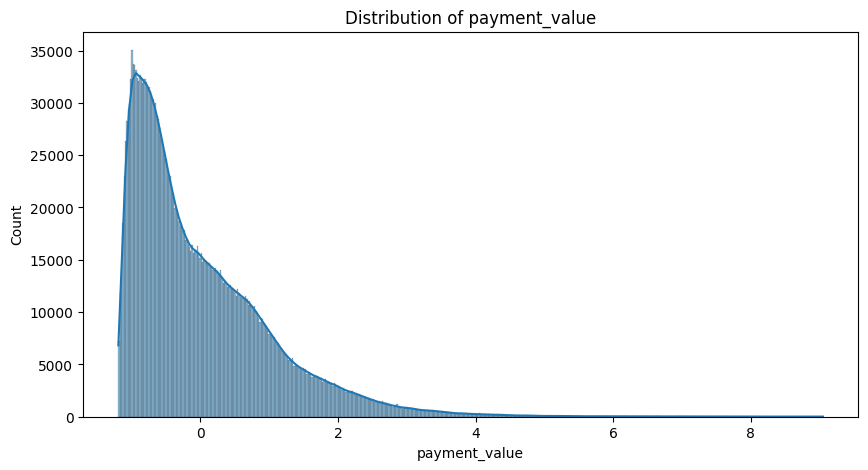

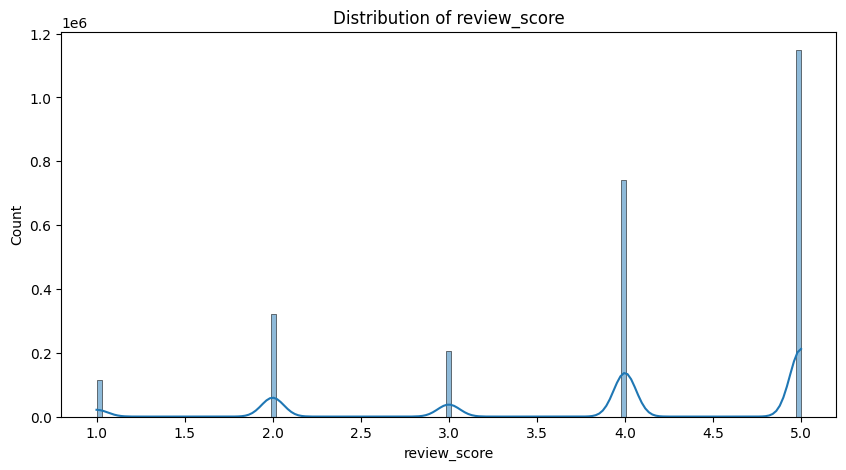

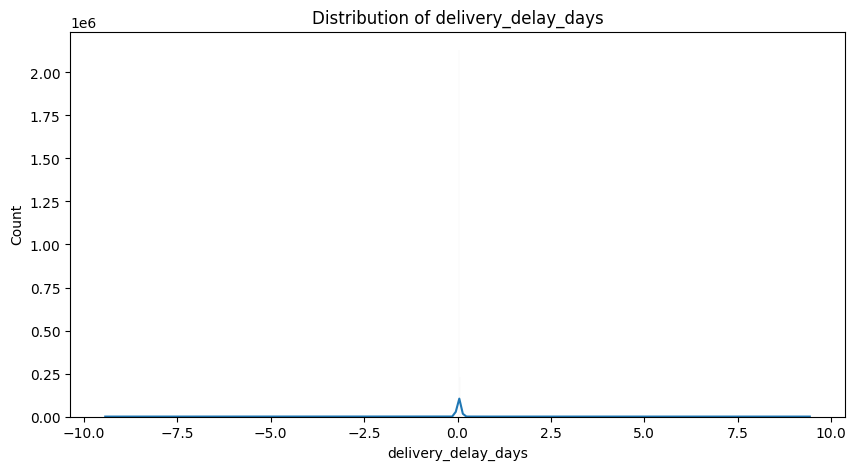

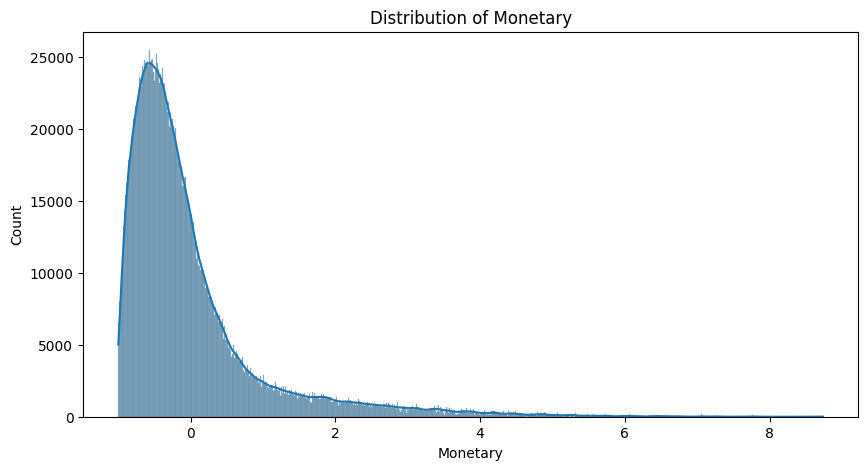

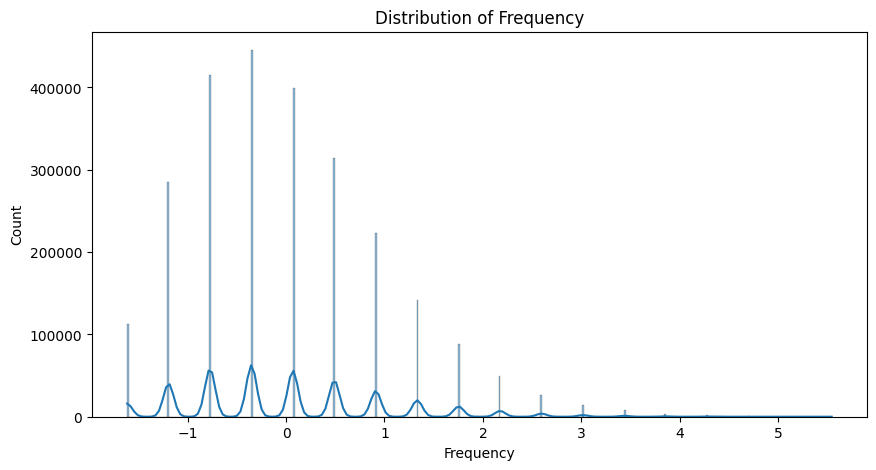

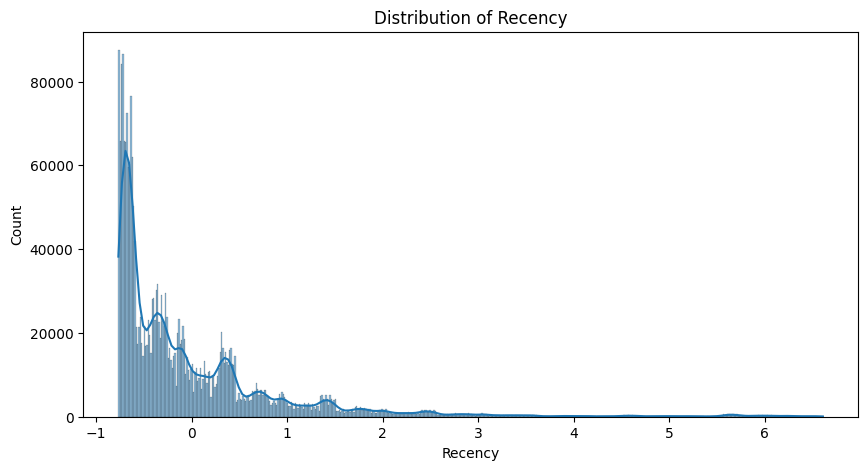

In [5]:
# =========================================================
# STEP 5 — DISTRIBUTION ANALYSIS
# =========================================================

distribution_cols = [

    'payment_value',
    'review_score',
    'delivery_delay_days',
    'Monetary',
    'Frequency',
    'Recency'
]

for col in distribution_cols:

    plt.figure(figsize=(10,5))

    sns.histplot(
        master_df[col],
        kde=True
    )

    plt.title(f"Distribution of {col}")

    plt.show()

In [6]:
# =========================================================
# STEP 6 — SKEWNESS & KURTOSIS
# =========================================================

print("\n================ SKEWNESS & KURTOSIS ================\n")

for col in distribution_cols:

    col_skewness = skew(
        master_df[col].dropna()
    )

    col_kurtosis = kurtosis(
        master_df[col].dropna()
    )

    print(f"\n{col}")
    print(f"Skewness : {col_skewness:.2f}")
    print(f"Kurtosis : {col_kurtosis:.2f}")


================ SKEWNESS & KURTOSIS ================


payment_value
Skewness : 1.42
Kurtosis : 2.55

review_score
Skewness : -1.03
Kurtosis : -0.09

delivery_delay_days
Skewness : -1.38
Kurtosis : 39.23

Monetary
Skewness : 2.57
Kurtosis : 8.59

Frequency
Skewness : 0.77
Kurtosis : 0.69

Recency
Skewness : 2.84
Kurtosis : 11.04


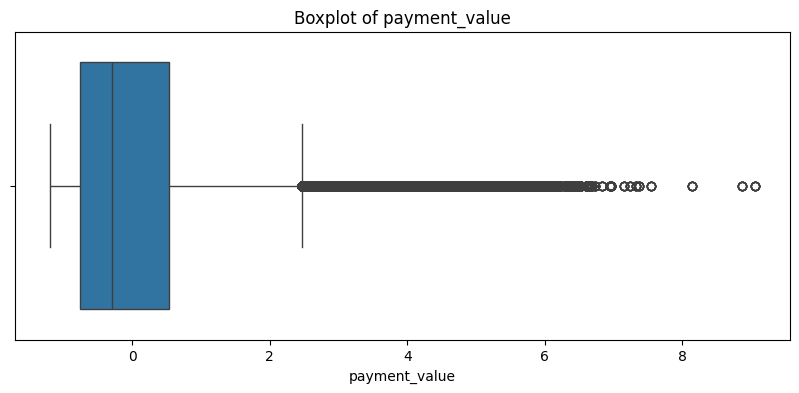

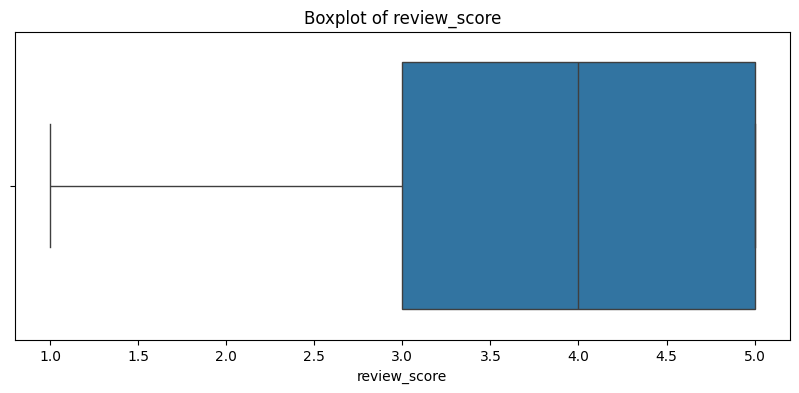

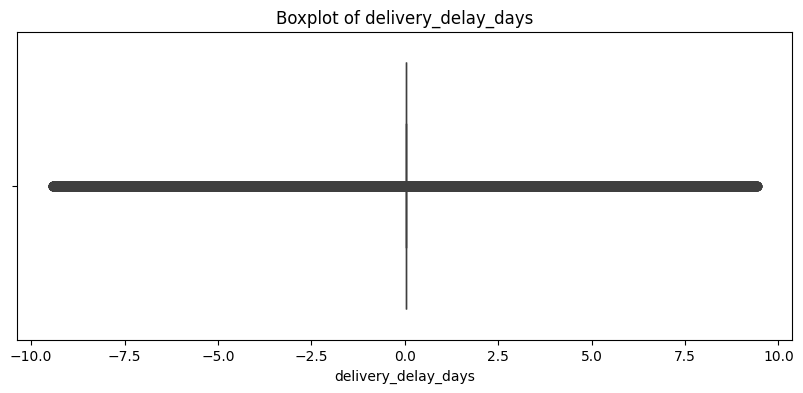

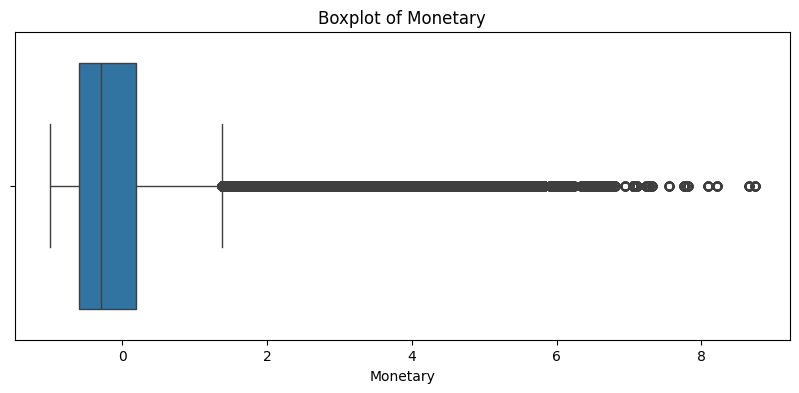

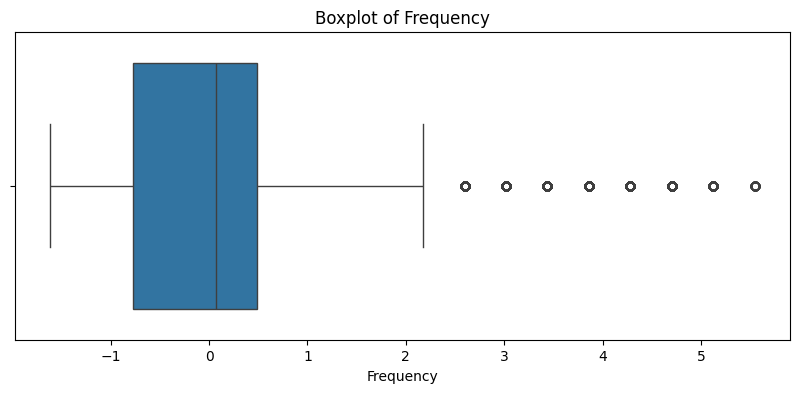

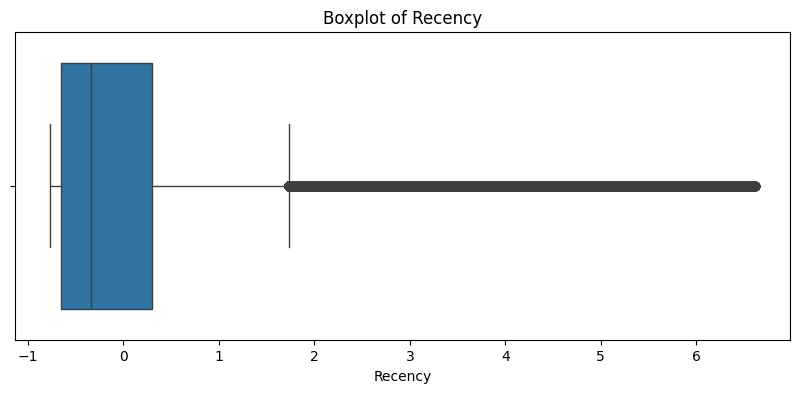

In [7]:
# =========================================================
# STEP 7 — BOXPLOT ANALYSIS
# =========================================================

for col in distribution_cols:

    plt.figure(figsize=(10,4))

    sns.boxplot(
        x=master_df[col]
    )

    plt.title(f"Boxplot of {col}")

    plt.show()

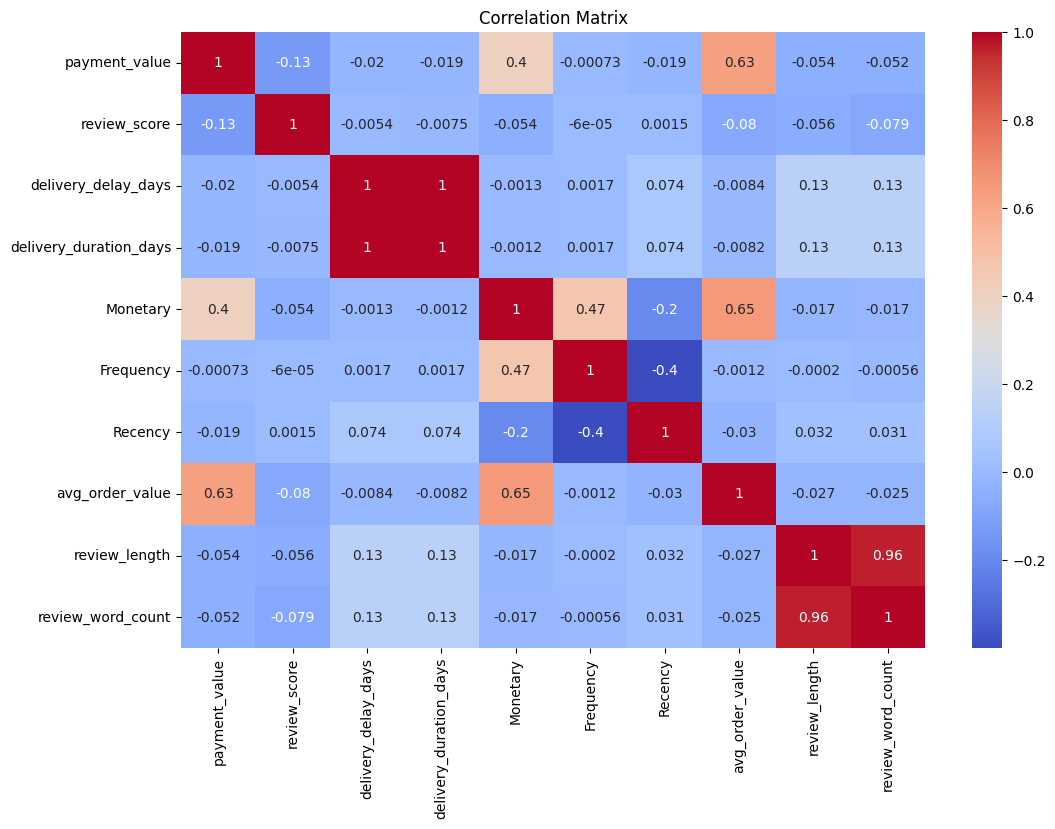

In [8]:
# =========================================================
# STEP 8 — CORRELATION ANALYSIS
# =========================================================

numerical_cols = [

    'payment_value',
    'review_score',
    'delivery_delay_days',
    'delivery_duration_days',
    'Monetary',
    'Frequency',
    'Recency',
    'avg_order_value',
    'review_length',
    'review_word_count'
]

corr_matrix = (
    master_df[numerical_cols]
    .corr()
)

plt.figure(figsize=(12,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")

plt.show()

In [9]:
# =========================================================
# STEP 9 — PEARSON CORRELATION TEST
# =========================================================

print("\n================ PEARSON CORRELATION ================\n")

pearson_corr, pearson_p = pearsonr(

    master_df['delivery_delay_days'],
    master_df['review_score']
)

print(f"Correlation Coefficient : {pearson_corr:.4f}")
print(f"P-Value                 : {pearson_p:.4f}")


================ PEARSON CORRELATION ================

Correlation Coefficient : -0.0054
P-Value                 : 0.0000


In [10]:
# =========================================================
# STEP 10 — SPEARMAN CORRELATION TEST
# =========================================================

print("\n================ SPEARMAN CORRELATION ================\n")

spearman_corr, spearman_p = spearmanr(

    master_df['delivery_delay_days'],
    master_df['review_score']
)

print(f"Correlation Coefficient : {spearman_corr:.4f}")
print(f"P-Value                 : {spearman_p:.4f}")


================ SPEARMAN CORRELATION ================

Correlation Coefficient : -0.3693
P-Value                 : 0.0000


In [11]:
# =========================================================
# STEP 11 — HYPOTHESIS TESTING (T-TEST)
# =========================================================

print("\n================ T-TEST ================\n")

vip_customers = master_df[
    master_df['customer_segment'] == 2
]['payment_value']

consumer_customers = master_df[
    master_df['customer_segment'] == 0
]['payment_value']

t_stat, p_value = ttest_ind(
    vip_customers,
    consumer_customers
)

print(f"T-Statistic : {t_stat:.4f}")
print(f"P-Value     : {p_value:.4f}")

if p_value < 0.05:

    print("\nResult: Significant Difference Exists")

else:

    print("\nResult: No Significant Difference")


================ T-TEST ================

T-Statistic : 556.5055
P-Value     : 0.0000

Result: Significant Difference Exists


In [12]:
# =========================================================
# STEP 12 — ANOVA TEST
# =========================================================

print("\n================ ANOVA TEST ================\n")

credit_card = master_df[
    master_df['payment_type'] == 1
]['payment_value']

debit_card = master_df[
    master_df['payment_type'] == 2
]['payment_value']

paypal = master_df[
    master_df['payment_type'] == 4
]['payment_value']

f_stat, anova_p = f_oneway(

    credit_card,
    debit_card,
    paypal
)

print(f"F-Statistic : {f_stat:.4f}")
print(f"P-Value     : {anova_p:.4f}")

if anova_p < 0.05:

    print("\nResult: Payment Methods Differ Significantly")

else:

    print("\nResult: No Significant Difference")


================ ANOVA TEST ================

F-Statistic : 7201.0567
P-Value     : 0.0000

Result: Payment Methods Differ Significantly


In [13]:
# =========================================================
# STEP 13 — OUTLIER ANALYSIS USING Z-SCORE
# =========================================================

print("\n================ Z-SCORE OUTLIERS ================\n")

zscore_cols = [

    'payment_value',
    'Monetary',
    'avg_order_value'
]

for col in zscore_cols:

    z_scores = np.abs(
        zscore(master_df[col])
    )

    outliers = (
        z_scores > 3
    ).sum()

    print(f"{col} --> Outliers: {outliers}")


================ Z-SCORE OUTLIERS ================

payment_value --> Outliers: 34992
Monetary --> Outliers: 65695
avg_order_value --> Outliers: 31744


In [14]:
# =========================================================
# STEP 14 — CUSTOMER SEGMENT ANALYSIS
# =========================================================

segment_analysis = (

    master_df.groupby('customer_segment')

    .agg({

        'payment_value': 'mean',

        'Frequency': 'mean',

        'Monetary': 'mean',

        'review_score': 'mean'

    })

)

print("\nCustomer Segment Analysis:\n")

display(segment_analysis)


Customer Segment Analysis:



,payment_value,Frequency,Monetary,review_score
customer_segment,,,,
0,-0.161469,-0.001438,-0.321680,4.010416
1,-0.163773,0.006139,-0.321454,4.010013
2,0.730094,-0.001085,1.449685,3.860193


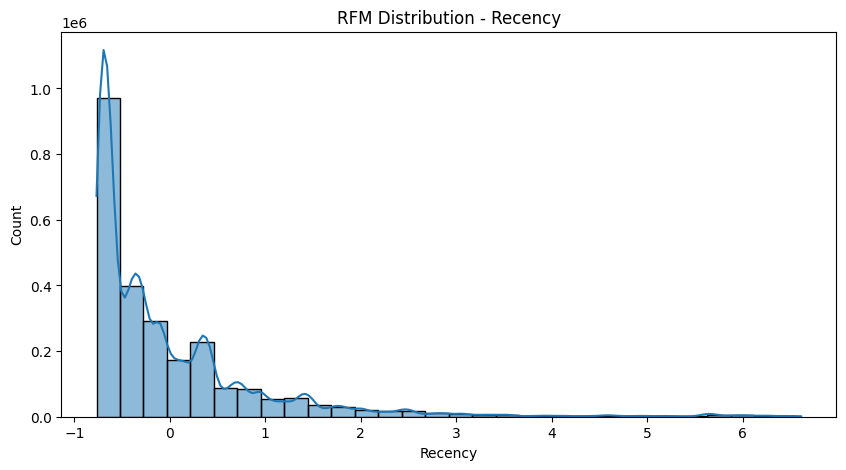

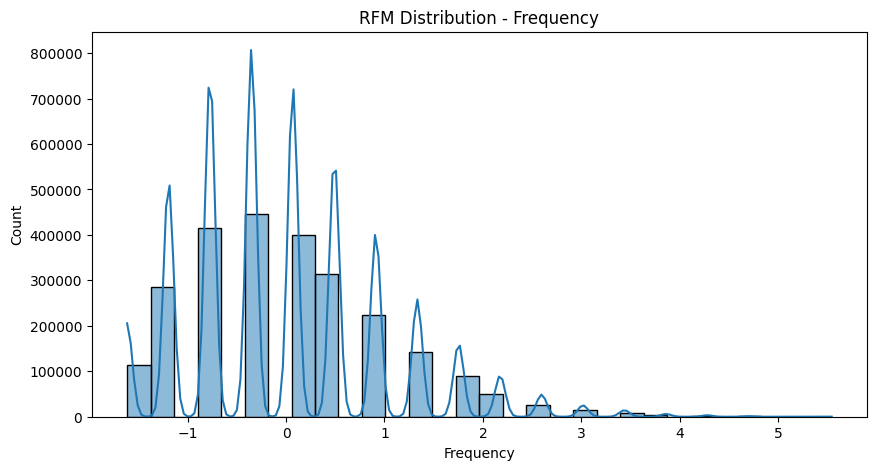

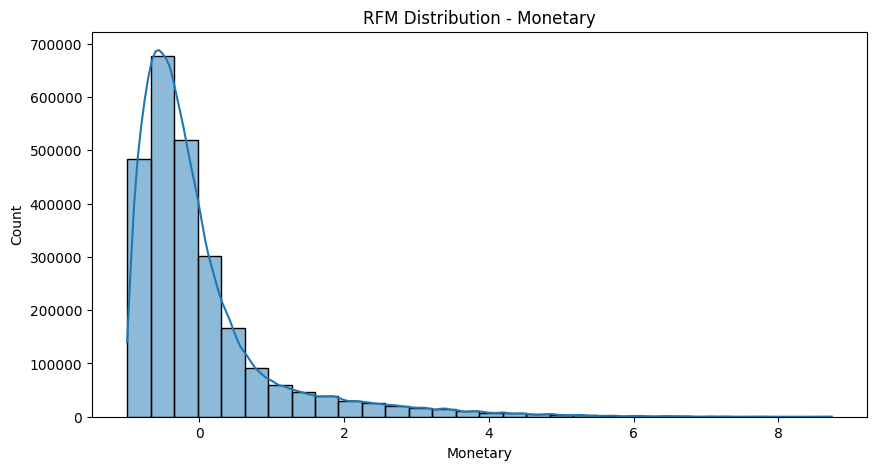

In [15]:
# =========================================================
# STEP 15 — RFM DISTRIBUTION ANALYSIS
# =========================================================

rfm_cols = [

    'Recency',
    'Frequency',
    'Monetary'
]

for col in rfm_cols:

    plt.figure(figsize=(10,5))

    sns.histplot(
        master_df[col],
        bins=30,
        kde=True
    )

    plt.title(f"RFM Distribution - {col}")

    plt.show()

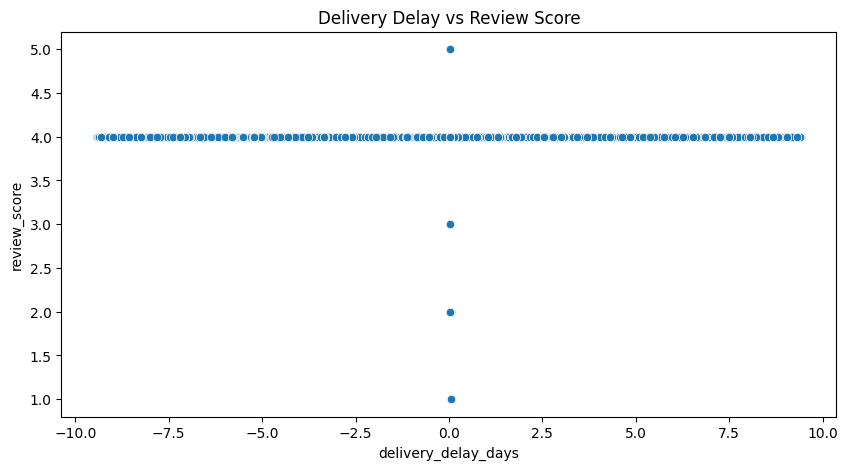

In [16]:
# =========================================================
# STEP 16 — DELIVERY DELAY ANALYSIS
# =========================================================

plt.figure(figsize=(10,5))

sns.scatterplot(

    x='delivery_delay_days',
    y='review_score',
    data=master_df
)

plt.title("Delivery Delay vs Review Score")

plt.show()

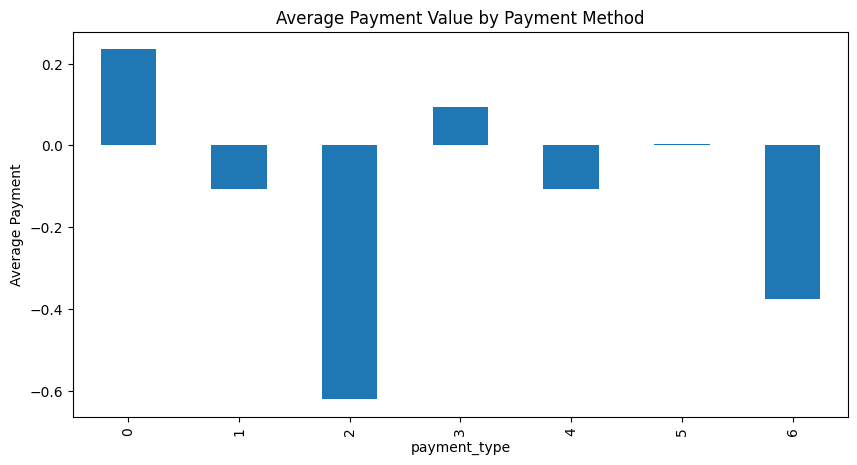

In [17]:
# =========================================================
# STEP 17 — PAYMENT METHOD ANALYSIS
# =========================================================

payment_analysis = (

    master_df.groupby('payment_type')['payment_value']
    .mean()
)

plt.figure(figsize=(10,5))

payment_analysis.plot(kind='bar')

plt.title("Average Payment Value by Payment Method")

plt.ylabel("Average Payment")

plt.show()

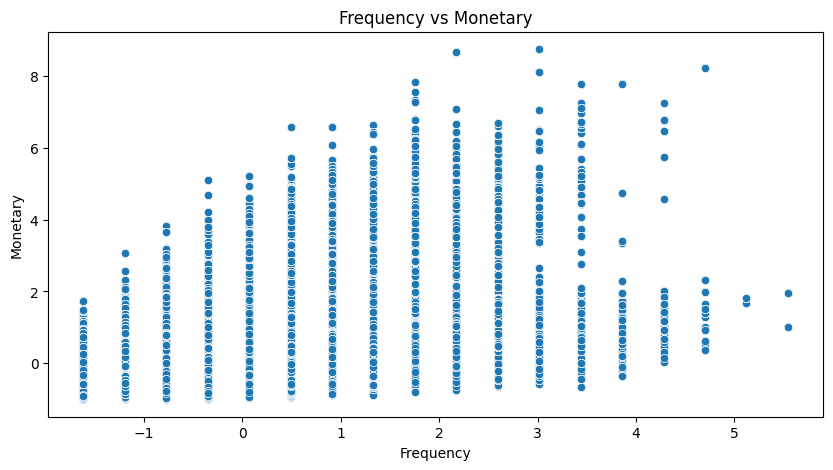

In [18]:
# =========================================================
# STEP 18 — CUSTOMER SPENDING ANALYSIS
# =========================================================

plt.figure(figsize=(10,5))

sns.scatterplot(

    x='Frequency',
    y='Monetary',
    data=master_df
)

plt.title("Frequency vs Monetary")

plt.show()

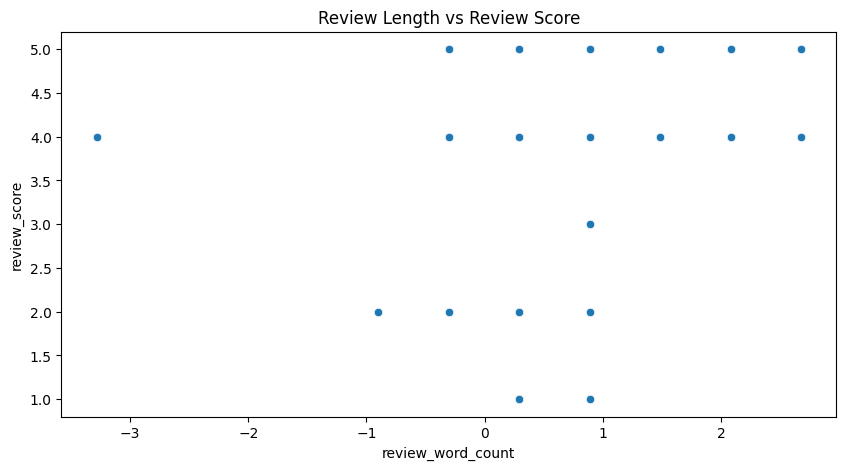

In [19]:
# =========================================================
# STEP 19 — REVIEW LENGTH ANALYSIS
# =========================================================

plt.figure(figsize=(10,5))

sns.scatterplot(

    x='review_word_count',
    y='review_score',
    data=master_df
)

plt.title("Review Length vs Review Score")

plt.show()

In [20]:
# =========================================================
# STEP 20 — MULTICOLLINEARITY CHECK
# =========================================================

print("\n================ MULTICOLLINEARITY CHECK ================\n")

high_corr_pairs = []

for i in range(len(corr_matrix.columns)):

    for j in range(i):

        if abs(corr_matrix.iloc[i, j]) > 0.8:

            col1 = corr_matrix.columns[i]
            col2 = corr_matrix.columns[j]

            corr_value = corr_matrix.iloc[i, j]

            high_corr_pairs.append(
                (col1, col2, corr_value)
            )

for pair in high_corr_pairs:

    print(
        f"{pair[0]} <--> {pair[1]} : {pair[2]:.2f}"
    )


================ MULTICOLLINEARITY CHECK ================

delivery_duration_days <--> delivery_delay_days : 1.00
review_word_count <--> review_length : 0.96


In [21]:
# =========================================================
# STEP 21 — FEATURE IMPORTANCE PREVIEW
# =========================================================

importance_cols = [

    'Frequency',
    'Monetary',
    'avg_order_value',
    'review_score',
    'delivery_delay_days'
]

importance_df = (

    master_df[importance_cols]
    .corrwith(master_df['churn'])
    .sort_values(ascending=False)
)

print("\nFeature Correlation with Churn:\n")

print(importance_df)



Feature Correlation with Churn:

delivery_delay_days    0.070940
review_score           0.004147
avg_order_value       -0.076915
Monetary              -0.167597
Frequency             -0.290137
dtype: float64


In [22]:
# =========================================================
# STEP 22 — BUSINESS INSIGHTS
# =========================================================

print("\n===================================================")
print("STATISTICAL ANALYSIS INSIGHTS")
print("===================================================")

print("""

1. Analyzed customer purchase behavior distributions.

2. Identified skewness and outlier characteristics.

3. Evaluated delivery delays and customer satisfaction relationships.

4. Compared customer segments using statistical testing.

5. Analyzed payment-method behavioral differences.

6. Studied RFM behavioral distributions.

7. Performed multicollinearity analysis.

8. Explored feature relationships with churn behavior.

9. Validated statistical significance using:
   - T-Test
   - ANOVA
   - Pearson Correlation
   - Spearman Correlation

10. Identified candidate features for predictive modeling.

""")



STATISTICAL ANALYSIS INSIGHTS


1. Analyzed customer purchase behavior distributions.

2. Identified skewness and outlier characteristics.

3. Evaluated delivery delays and customer satisfaction relationships.

4. Compared customer segments using statistical testing.

5. Analyzed payment-method behavioral differences.

6. Studied RFM behavioral distributions.

7. Performed multicollinearity analysis.

8. Explored feature relationships with churn behavior.

9. Validated statistical significance using:
   - T-Test
   - ANOVA
   - Pearson Correlation
   - Spearman Correlation

10. Identified candidate features for predictive modeling.




In [23]:
# =========================================================
# STEP 23 — SAVE ANALYSIS-READY DATASET
# =========================================================

master_df.to_csv(

    r'C:\Users\niran\Desktop\AI_Ecommerce_Customer_Intelligence_Platform\data\processed\statistical_analysis_dataset.csv',

    index=False
)

print("\nStatistical Analysis Dataset Saved Successfully")



Statistical Analysis Dataset Saved Successfully


In [24]:
# =========================================================
# STEP 24 — NOTEBOOK COMPLETION
# =========================================================

print("\n===================================================")
print("05_statistical_analysis.ipynb COMPLETED SUCCESSFULLY")
print("===================================================")


05_statistical_analysis.ipynb COMPLETED SUCCESSFULLY
